# Two steps Neural Networks

In [19]:
######### LIBRARIES ############
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
from keras.models import save_model
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from ann_functions3D import getModel, kCrossVal, transfBestparam, import_data
from time import perf_counter
import pandas
import pickle
import os
from itertools import product

seed = 7
np.random.seed(seed)

## Data preparation

In [20]:
file_path_D = os.path.join("..", "..", "Diffusion\DATA", "Discretizations.txt")
file_path_diff = os.path.join("..", "..", "Diffusion\DATA", "diffusion.txt")



Discretizations= np.loadtxt(
    file_path_D
).astype(
    int
)

diffusion= np.loadtxt(
    file_path_diff
).astype(
    int
)

In [21]:
########################     PREPARATION      ##########################
# introduction of the data
file_path_HF = os.path.join("..", "..", "Diffusion\DATA", "reaction_diffusion_HF.mat")
(reaction_HF_test, U_HF_test, x_HF_test) = import_data(file_path_HF)

In [22]:
########################     NORMALIZATION  #########################
# Input

reaction_max = np.max(reaction_HF_test)
reaction_min = np.min(reaction_HF_test)

reaction_HF_test = (reaction_HF_test - reaction_min) / (
    reaction_max - reaction_min
)

In [23]:
#########################     TRAIN SET      ##########################
NepoLF = 5000  # number of epochs for first NN: NN_LF
NepoHF = 5000  # number of epochs for second NN: NN_HF

Nlf = 30


In [24]:
# TRANSFORMATION

permutation1 = np.random.permutation(len(reaction_HF_test))
permutation2 = np.random.permutation(len(x_HF_test))
n_HF = 15

reaction_HF = reaction_HF_test[permutation1][0:n_HF]
x_HF = x_HF_test[permutation2][0:n_HF]
grid1, grid2 = np.meshgrid(reaction_HF, x_HF)
reaction_HF = np.column_stack((grid1.ravel(), grid2.ravel()))
U_HF_test = U_HF_test[:, -1, :,44]

reaction_HF_test = np.array(list(product(reaction_HF_test.flatten(), x_HF_test.flatten())))

#
reaction_HF=np.c_[reaction_HF, np.abs(np.sin(5*np.pi*reaction_HF[:, 0])),np.abs(np.sin(0.2*np.pi*reaction_HF[:, 1]))]
reaction_HF_test=np.c_[reaction_HF_test, np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0])),np.abs(np.sin(0.2*np.pi*reaction_HF_test[:, 1]))]
#


# TRANSFORMATION
U_h_max_test = np.max(U_HF_test)
U_h_min_test = np.min(U_HF_test)
#U_HF = (U_HF - U_h_min_test) / (U_h_max_test - U_h_min_test)
U_HF_test = (U_HF_test - U_h_min_test) / (U_h_max_test - U_h_min_test)

##
p1, p2 = np.meshgrid(permutation1[0:n_HF], permutation2[0:n_HF])
permutation = np.column_stack((p1.ravel(), p2.ravel()))
U_HF = U_HF_test[permutation[:,0],permutation[:,1]]
row, col = U_HF_test.shape
index_row, index_col = np.meshgrid(np.arange(row), np.arange(col), indexing='ij')
comb = np.ravel_multi_index((index_row.flatten(), index_col.flatten()), dims=(row, col))
U_HF_test = U_HF_test.flatten()[comb]
##

In [25]:
U_LF_list = []
U_HF_list = []

r2_HF_df = pandas.DataFrame(columns=['Discretization','diffusion','R2'])  # dataframe which stores HF R^2
r2_LF_df = pandas.DataFrame(columns=['Discretization','diffusion','R2'])  # dataframe which stores LF R^2
mse_HF_df = pandas.DataFrame(columns=['Discretization','diffusion','MSE'])  # dataframe which stores HF MSE
mse_LF_df = pandas.DataFrame(columns=['Discretization','diffusion','MSE'])  # dataframe which stores LF MSE

In [26]:
print(diffusion[-1])

1


********************  # Nb. nodes = 10  ********************
********************  # Diff: = 0  ********************
LF NN done
16/16 [==============================] - 0s 2ms/step

LF Model:
Test MSE: 0.12500669598613462
R^2: -0.001246462330164233
157/157 [==============================] - 0s 2ms/step
Elapsed time:  286.67303270002594

HF Model:
Test MSE: 0.11343210326184308
R^2: -0.015814818220184934
4/4 [==============================] - 0s 2ms/step


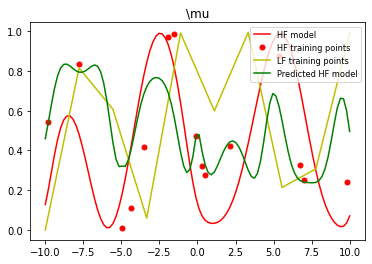

2/2 [==============================] - 0s 4ms/step


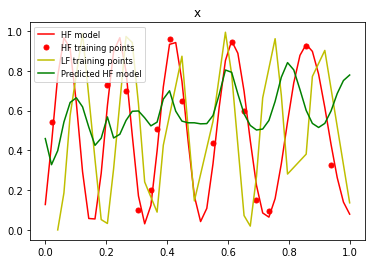

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:203: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:205: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:207: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:209: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 5  ********************
LF NN done
16/16 [==============================] - 0s 3ms/step

LF Model:
Test MSE: 0.12374072435903344
R^2: -0.00019726093144867285
157/157 [==============================] - 0s 2ms/step
Elapsed time:  272.18381849999423

HF Model:
Test MSE: 0.11637931752124382
R^2: -0.0422079100440953
4/4 [==============================] - 0s 3ms/step


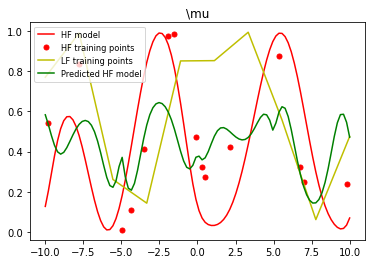

2/2 [==============================] - 0s 8ms/step


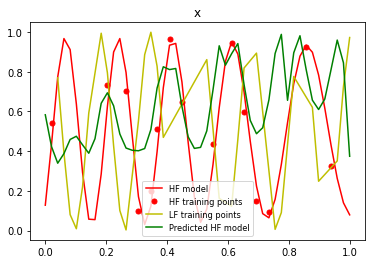

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:203: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:205: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:207: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:209: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 75  ********************
LF NN done
16/16 [==============================] - 0s 2ms/step

LF Model:
Test MSE: 0.12305472262053516
R^2: -0.0017261347833026353
157/157 [==============================] - 0s 2ms/step
Elapsed time:  241.94508229999337

HF Model:
Test MSE: 0.11902570253601434
R^2: -0.06590699553591861
4/4 [==============================] - 0s 2ms/step


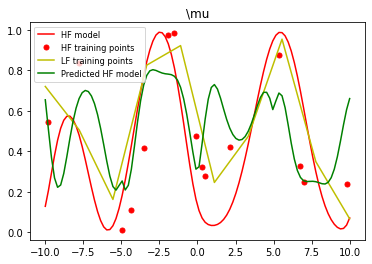

2/2 [==============================] - 0s 5ms/step


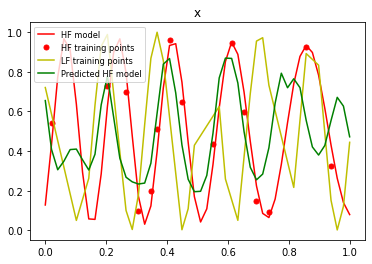

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:203: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:205: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:207: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:209: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 1  ********************
LF NN done
16/16 [==============================] - 0s 2ms/step

LF Model:
Test MSE: 0.11999255046545323
R^2: -0.006122369355602508
157/157 [==============================] - 0s 2ms/step
Elapsed time:  254.26136079998105

HF Model:
Test MSE: 0.11876612474412422
R^2: -0.06358240699439976
4/4 [==============================] - 0s 2ms/step


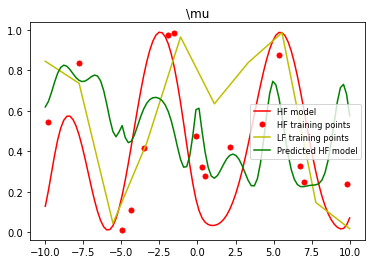

2/2 [==============================] - 0s 4ms/step


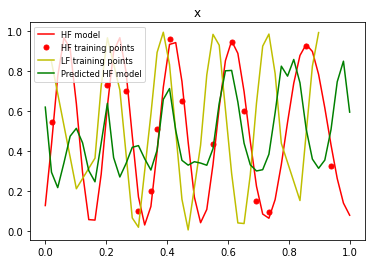

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:203: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:205: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:207: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:209: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 0  ********************
LF NN done
44/44 [==============================] - 1s 3ms/step

LF Model:
Test MSE: 0.1247591297029747
R^2: -0.0003170808052772589
157/157 [==============================] - 0s 2ms/step
Elapsed time:  240.18396609998308

HF Model:
Test MSE: 0.11580136823791447
R^2: -0.03703221965924497
4/4 [==============================] - 0s 2ms/step


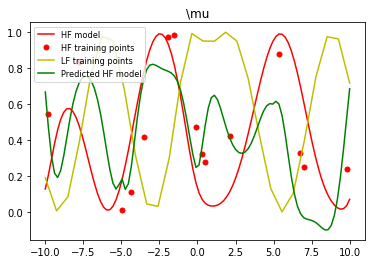

2/2 [==============================] - 0s 3ms/step


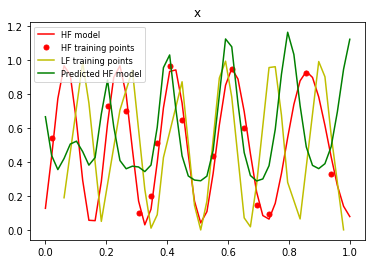

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:203: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:205: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:207: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:209: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 5  ********************
LF NN done
44/44 [==============================] - 0s 2ms/step

LF Model:
Test MSE: 0.11211890973654923
R^2: -0.0013558502604598122
157/157 [==============================] - 0s 2ms/step
Elapsed time:  10449.224659800006

HF Model:
Test MSE: 0.11674067645660789
R^2: -0.045443975943285864
4/4 [==============================] - 0s 2ms/step


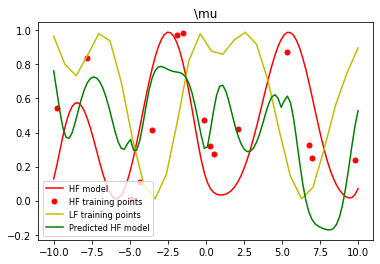

2/2 [==============================] - 0s 3ms/step


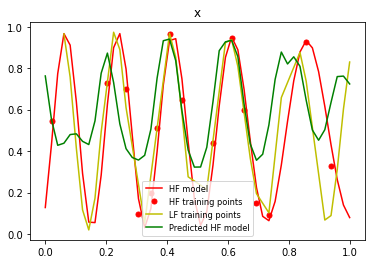

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:203: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:205: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:207: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:209: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 75  ********************
LF NN done
44/44 [==============================] - 0s 2ms/step

LF Model:
Test MSE: 0.10932445349740735
R^2: -0.006185873075948312
157/157 [==============================] - 0s 2ms/step
Elapsed time:  246.33050909999292

HF Model:
Test MSE: 0.11483005108703692
R^2: -0.02833381482780828
4/4 [==============================] - 0s 4ms/step


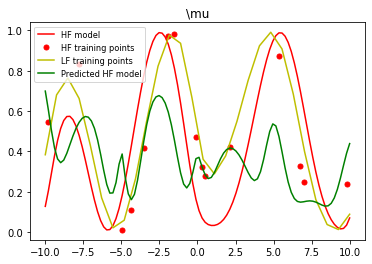

2/2 [==============================] - 0s 0s/step


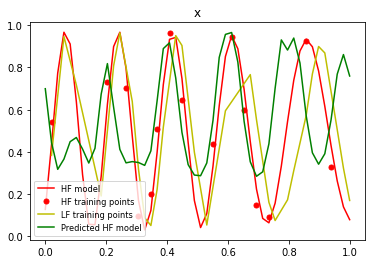

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:203: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:205: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:207: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:209: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 1  ********************
LF NN done
44/44 [==============================] - 0s 2ms/step

LF Model:
Test MSE: 0.10820842355324263
R^2: -0.006022287417628558
157/157 [==============================] - 0s 2ms/step
Elapsed time:  246.56253980001202

HF Model:
Test MSE: 0.11413457983576382
R^2: -0.022105683792817743
4/4 [==============================] - 0s 3ms/step


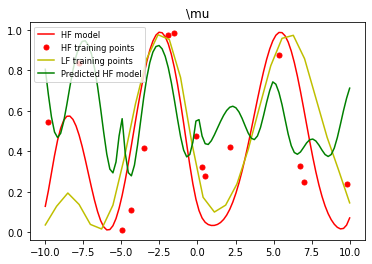

2/2 [==============================] - 0s 3ms/step


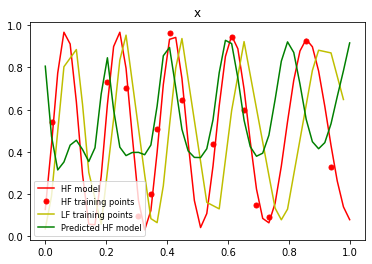

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:203: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:205: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:207: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:209: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 0  ********************
LF NN done
72/72 [==============================] - 0s 2ms/step

LF Model:
Test MSE: 0.12472823133105491
R^2: -7.865013000962762e-05
157/157 [==============================] - 0s 2ms/step
Elapsed time:  261.30745339998975

HF Model:
Test MSE: 0.1299964400339969
R^2: -0.16415288357635727
4/4 [==============================] - 0s 2ms/step


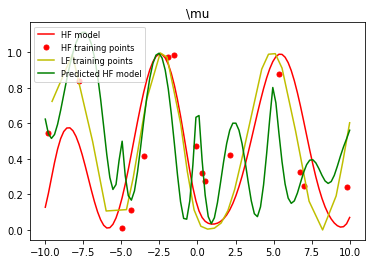

2/2 [==============================] - 0s 3ms/step


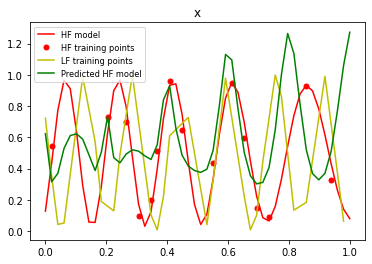

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:203: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:205: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:207: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:209: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 5  ********************
LF NN done
72/72 [==============================] - 0s 2ms/step

LF Model:
Test MSE: 0.11101402414072571
R^2: -0.004588057845956284
157/157 [==============================] - 0s 2ms/step
Elapsed time:  245.77523440000368

HF Model:
Test MSE: 0.11869344201753868
R^2: -0.06293151374133354
4/4 [==============================] - 0s 2ms/step


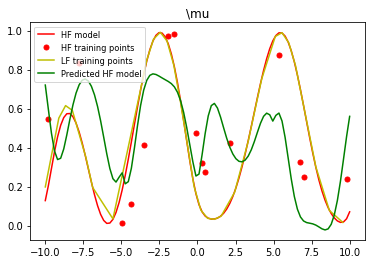

2/2 [==============================] - 0s 0s/step


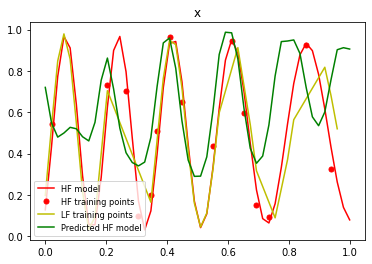

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:203: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:205: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:207: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:209: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 75  ********************
LF NN done
72/72 [==============================] - 0s 2ms/step

LF Model:
Test MSE: 0.11020197238034764
R^2: -0.0015221443385755595
157/157 [==============================] - 0s 2ms/step
Elapsed time:  249.44911879999563

HF Model:
Test MSE: 0.10953529858911781
R^2: 0.019082109690306548
4/4 [==============================] - 0s 2ms/step


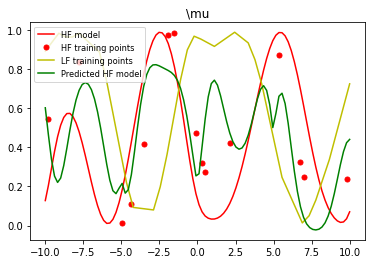

2/2 [==============================] - 0s 6ms/step


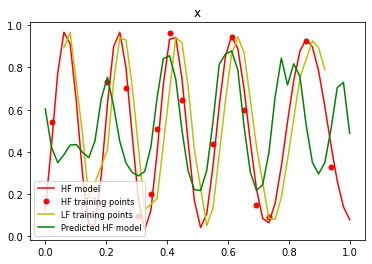

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:203: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:205: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:207: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:209: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 1  ********************
LF NN done
72/72 [==============================] - 0s 2ms/step

LF Model:
Test MSE: 0.10974868129218536
R^2: -0.004003533664197034
157/157 [==============================] - 0s 2ms/step
Elapsed time:  246.7712029000104

HF Model:
Test MSE: 0.1192988090353828
R^2: -0.06835273727069291
4/4 [==============================] - 0s 2ms/step


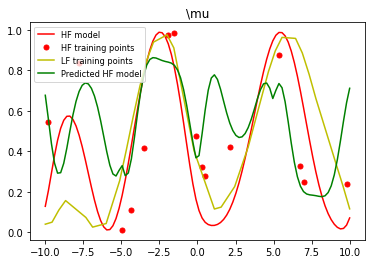

2/2 [==============================] - 0s 3ms/step


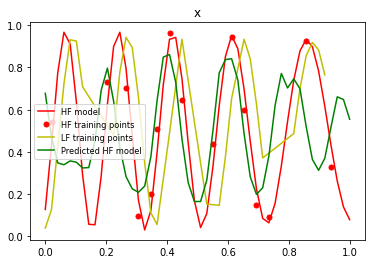

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:203: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:205: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:207: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12484\3541520225.py:209: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

    Discretization  diffusion       R2
0             10.0        0.0 -0.06520
1             10.0        5.0 -0.04240
2             10.0       75.0 -0.03961
3             10.0        1.0 -0.24946
4             10.0        0.0 -0.01581
5             10.0        5.0 -0.04221
6             10.0       75.0 -0.06591
7             10.0        1.0 -0.06358
8             28.0        0.0 -0.03703
9             28.0        5.0 -0.04544
10            28.0       75.0 -0.02833
11            28.0        1.0 -0.02211
12            46.0        0.0 -0.16415
13            46.0        5.0 -0.06293
14            46.0       75.0  0.01908
15            46.0        1.0 -0.06835
    Discretization  diffusion      MSE
0             10.0        0.0  0.11895
1             10.0        5.0  0.11640
2             10.0       75.0  0.11609
3             10.0        1.0  0.13952
4             10.0        0.0  0.11343
5             10.0        5.0  0.11638
6             10.0       75.0  0.11903
7             10.0       

In [28]:

test_mse_HF_list = []
test_mse_LF_list = []

r2_HF_list = []
r2_LF_list = []

for m in range(len(Discretizations)):
    for d in range(len(diffusion)):
        file_name= os.path.join("..", "..", "Diffusion\DATA", "reaction_diffusion_LF_"+str(Discretizations[m])+"_d"+str(diffusion[d])+".mat")
        #file_name="Diffusion\DATA\reaction_diffusion_LF_"+str(Discretizations[m])+"_d"+str(diffusion[d])+".mat"
        (reaction_LF_test, U_LF_test, x_LF_test) = import_data(file_name)
#file_path_LF = "..\..\Diffusion\DATA\reaction_diffusion_LF_46_d75.mat"
        
        reaction_max = np.max(reaction_LF_test)
        reaction_min = np.min(reaction_LF_test)
        reaction_LF_test = (reaction_LF_test - reaction_min) / (
            reaction_max - reaction_min
        )
        
        L=np.minimum(Nlf,x_LF_test.shape[0])
        permutation1 = np.random.permutation(len(reaction_LF_test))
        permutation2 = np.random.permutation(len(x_LF_test))
        reaction_LF = reaction_LF_test[permutation1][0:Nlf]    # problema di consistenza qui: non stai confrontando stesso numero di dati, ma è cosairreparabile se non creando nuovo dataset
        x_LF = x_LF_test[permutation2][0:L]
        
        grid1, grid2 = np.meshgrid(reaction_LF, x_LF)
        reaction_LF = np.column_stack((grid1.ravel(), grid2.ravel()))
        reaction_LF_test = np.array(list(product(reaction_LF_test.flatten(), x_LF_test.flatten())))
        U_LF_test = U_LF_test[
        :,
        - 1,
        :,
        int(4*(Discretizations[m]-1)/9)
        ]
        
        #
        reaction_LF=np.c_[reaction_LF, np.abs(np.sin(5*np.pi*reaction_LF[:, 0])),np.abs(np.sin(0.2*np.pi*reaction_LF[:, 1]))]
        reaction_LF_test=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0])),np.abs(np.sin(0.2*np.pi*reaction_LF_test[:, 1]))]
        #
        
        # TRANSFORMATION
        U_t_max_test = np.max(U_LF_test)
        U_t_min_test = np.min(U_LF_test)

        U_LF_test = (U_LF_test - U_t_min_test) / (U_t_max_test - U_t_min_test)
        #U_HF = (U_HF - U_h_min_test) / (U_h_max_test - U_h_min_test)
        
        
        p1, p2 = np.meshgrid(permutation1[0:Nlf], permutation2[0:L])
        permutation = np.column_stack((p1.ravel(), p2.ravel()))
        U_train_LF = U_LF_test[permutation[:,0],permutation[:,1]]
        #U_train_LF = U_LF_test[permutation1[0:L],permutation2[0:L]]
        
        ##
        row, col = U_LF_test.shape
        index_row, index_col = np.meshgrid(np.arange(row), np.arange(col), indexing='ij')
        comb = np.ravel_multi_index((index_row.flatten(), index_col.flatten()), dims=(row, col))
        U_LF_test = U_LF_test.flatten()[comb]
        ##      


        print(
        f"********************  # Nb. nodes = {Discretizations[m]}  ********************"
        )
        
        print(
        f"********************  # Diff: = {diffusion[d]}  ********************"
        )
        
        ##########################       FIRST NN: NN_LF     ##########################
        K.clear_session()
        bestLF_params = {
            "lr": 0.0255,
            "kernel_init": "glorot_uniform",
            "opt": "Adam",
        } 

        
        modelLF = getModel(bestLF_params, "LF")  # ann_functions
        histLF = modelLF.fit(
            reaction_LF, U_train_LF, epochs=NepoLF, batch_size=Nlf, verbose=0
        )
        #        histLF = modelLF.fit(Young_LF_norm[:,0], U_train_LF ,epochs=NepoLF,batch_size=Nlf, verbose = 0)
        print("LF NN done")

        ULF = modelLF.predict(reaction_LF_test)

        U_LF_list.append(ULF)
        print("\nLF Model:")
        
        test_mse = np.mean(np.square(U_LF_test - ULF[:, 0]))
        test_mse_LF_list.append(test_mse)
        print(f"Test MSE: {test_mse}")

        r_2 = 1 - np.sum(np.square(U_LF_test - ULF[:, 0])) / np.sum(
            np.square(U_LF_test - np.mean(U_LF_test))
        )
        r2_LF_list.append(r_2)
        print(f"R^2: {r_2}")
        
        start = perf_counter()
        reaction_test_help = modelLF.predict(reaction_HF_test)[:, 0]
        reaction_test_in = np.concatenate(
        (reaction_HF_test, reaction_test_help.reshape(-1,1)),axis=1
        )   # <- TEST INPUT for the second NN: NN_HF

        reaction_train_help = modelLF.predict(reaction_HF)[
            :, 0
        ]  # f_LF(mu_hf_train)
        reaction_final = np.concatenate(
        (reaction_HF, reaction_train_help.reshape(-1,1)),axis=1
        )  # <- TRAINING INPUT for the second NN: NN_HF

        name = "2step"
        K.clear_session()
        # best parameters obtained by HPO:

        best_params = {
            "kernel_init": "uniform",
            "l2weight": 0.0002588943618918075,
            "lr": 0.008365144388542751,
            "nodes": 6.0,
            "opt": "Adam",
        }
        
        
        finalModel = getModel(
            best_params, name
        )  # final model chosen according to the best paramters
        hist = finalModel.fit(
            reaction_final,
            U_HF,
            validation_data=(reaction_test_in, U_HF_test),
            epochs=NepoHF,
            batch_size=n_HF,
            verbose=0,
            validation_freq=20,
        )

        UHF = finalModel.predict(reaction_test_in)
        U_HF_list.append(UHF)

        stop = perf_counter()
        elapsed = stop - start
        print("Elapsed time: ", elapsed)
        print("\nHF Model:")

        test_mse = np.mean(np.square(U_HF_test - UHF[:, 0]))
        test_mse_HF_list.append(test_mse)
        print(f"Test MSE: {test_mse}")

        r2_HF = 1 - np.sum(np.square(U_HF_test - UHF[:, 0])) / np.sum(
            np.square(U_HF_test - np.mean(U_HF_test))
        )
        r2_HF_list.append(r2_HF)
        print(f"R^2: {r2_HF}")
        
        plt.figure()
        mask1_test=np.where(reaction_test_in[:,0]==np.min(reaction_test_in[:,0]))
        mask1=np.where(reaction_final[:,0]==np.min(reaction_final[:,0]))
        mask1_LF=np.where(reaction_LF[:,0]==np.min(reaction_LF[:,0]))
        order=np.argsort(reaction_LF[mask1_LF,1])
# plt.plot(mu_test, U_hf_test, 'b-', linewidth = 1.5, label = 'HF model')
# plt.plot(mu_train_HF, U_hf_train,'b*', markersize = 7, label = 'HF training points')
        plt.plot(reaction_test_in[mask1_test,1].T, U_HF_test[mask1_test], "r-", linewidth=1.5, label="HF model")
        plt.plot(reaction_final[mask1,1].T, U_HF[mask1], "ro", markersize=5, label="HF training points")
        plt.plot(reaction_LF[mask1_LF,1].T[order[0,:]], U_train_LF[mask1_LF][order[0,:]], "y-", markersize=5, label="LF training points")
        plt.plot(
        reaction_test_in[mask1_test, 1].T,
        finalModel.predict(reaction_test_in[mask1_test, :][0,:,:]),
        "g-",
        markersize=5,
        label="Predicted HF model",
        )

        plt.legend(prop={"size": 8.3})  
        plt.title("\mu")
        plt.show()

        plt.figure()
        mask2_test=np.where(reaction_test_in[:,1]==np.min(reaction_test_in[:,1]))
        mask2=np.where(reaction_final[:,1]==np.min(reaction_final[:,1]))    
        mask2_LF=np.where(reaction_LF[:,1]==np.min(reaction_LF[:,1]))
        order=np.argsort(reaction_LF[mask2_LF,0])
# plt.plot(mu_test, U_hf_test, 'b-', linewidth = 1.5, label = 'HF model')
# plt.plot(mu_train_HF, U_hf_train,'b*', markersize = 7, label = 'HF training points')
        plt.plot(reaction_test_in[mask2_test,0].T, U_HF_test[mask2_test], "r-", linewidth=1.5, label="HF model")
        plt.plot(reaction_final[mask2,0].T, U_HF[mask2], "ro", markersize=5, label="HF training points")
        plt.plot(reaction_LF[mask2_LF,0].T[order[0,:]], U_train_LF[mask2_LF][order[0,:]], "y-", markersize=5, label="LF training points")
        plt.plot(
        reaction_test_in[mask2_test, 0].T,
        finalModel.predict(reaction_test_in[mask2_test, :][0,:,:]),
        "g-",
        markersize=5,
        label="Predicted HF model",
        )

        plt.legend(prop={"size": 8.3})
        plt.title("x")
        plt.show()

        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_LF_list[-1]}
        r2_LF_df=r2_LF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_HF_list[-1]}
        r2_HF_df=r2_HF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_LF_list[-1]}
        mse_LF_df=mse_LF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_HF_list[-1]}
        mse_HF_df=mse_HF_df.append(new, ignore_index=True)
        
        if not r2_HF_list[:-1]:
            save_model(modelLF,"modelLF2NN.h5")
            save_model(finalModel,"finalModel2NN.h5")
        elif r2_HF_list[:-1] and r2_HF_list[-1] < max(r2_HF_list[:-1]):
            save_model(modelLF,"modelLF2NN.h5")
            save_model(finalModel,"finalModel2NN.h5")
        
print(r2_HF_df.round(5))
print(mse_HF_df.round(5))



4/4 [==============================] - 0s 4ms/step


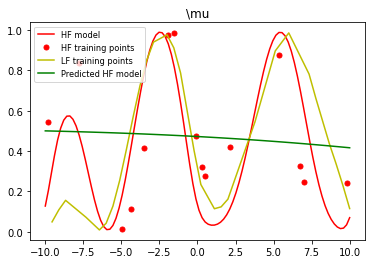

2/2 [==============================] - 0s 2ms/step


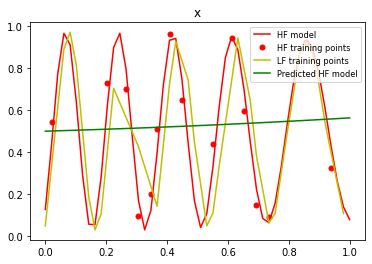

In [ ]:
        plt.figure()
        mask1_test=np.where(reaction_test_in[:,0]==np.min(reaction_test_in[:,0]))
        mask1=np.where(reaction_final[:,0]==np.min(reaction_final[:,0]))
        mask1_LF=np.where(reaction_LF[:,0]==np.min(reaction_LF[:,0]))
        
        order=np.argsort(reaction_LF[mask1_LF,1])
# plt.plot(mu_test, U_hf_test, 'b-', linewidth = 1.5, label = 'HF model')
# plt.plot(mu_train_HF, U_hf_train,'b*', markersize = 7, label = 'HF training points')
        plt.plot(reaction_test_in[mask1_test,1].T, U_HF_test[mask1_test], "r-", linewidth=1.5, label="HF model")
        plt.plot(reaction_final[mask1,1].T, U_HF[mask1], "ro", markersize=5, label="HF training points")
        plt.plot(reaction_LF[mask1_LF,1].T[order[0,:]], U_train_LF[mask1_LF][order[0,:]], "y-", markersize=5, label="LF training points")
        plt.plot(
        reaction_test_in[mask1_test, 1].T,
        finalModel.predict(reaction_test_in[mask1_test, :][0,:,:]),
        "g-",
        markersize=5,
        label="Predicted HF model",
        )

        plt.legend(prop={"size": 8.3})  
        plt.title("\mu")
        plt.show()

        plt.figure()
        mask2_test=np.where(reaction_test_in[:,1]==np.min(reaction_test_in[:,1]))
        mask2=np.where(reaction_final[:,1]==np.min(reaction_final[:,1]))    
        mask2_LF=np.where(reaction_LF[:,1]==np.min(reaction_LF[:,1]))
        order=np.argsort(reaction_LF[mask2_LF,0])
# plt.plot(mu_test, U_hf_test, 'b-', linewidth = 1.5, label = 'HF model')
# plt.plot(mu_train_HF, U_hf_train,'b*', markersize = 7, label = 'HF training points')
        plt.plot(reaction_test_in[mask2_test,0].T, U_HF_test[mask2_test], "r-", linewidth=1.5, label="HF model")
        plt.plot(reaction_final[mask2,0].T, U_HF[mask2], "ro", markersize=5, label="HF training points")
        plt.plot(reaction_LF[mask2_LF,0].T[order[0,:]], U_train_LF[mask2_LF][order[0,:]], "y-", markersize=5, label="LF training points")
        plt.plot(
        reaction_test_in[mask2_test, 0].T,
        finalModel.predict(reaction_test_in[mask2_test, :][0,:,:]),
        "g-",
        markersize=5,
        label="Predicted HF model",
        )

        plt.legend(prop={"size": 8.3})
        plt.title("x")
        plt.show()


        plt.figure()
        plt.plot(
        reaction_test_in[:, 0], U_HF_test, "ro", linewidth=1.5, label="HF model"
        )
        plt.plot(
        reaction_final[:, 0],
        U_HF,
        "r*",
        markersize=5,
        label="HF training points",
        )
        plt.plot(
        reaction_LF,
        U_train_LF,
        "y*",
        markersize=5,
        label="LF training points",
        )
        plt.plot(
        reaction_test_in[:, 0],
        finalModel.predict(reaction_test_in),
        "g*",
        linewidth=3,
        label="Predicted HF model",
        )
        plt.legend(prop={"size": 8.3})
        plt.show()

## Save the output

In [ ]:
os.makedirs("MF_LF_30_5000_HF_15_3000_2NN_multiparam")

r2_HF_df.to_csv(
    "./MF_LF_30_5000_HF_15_3000_2NN_multiparam/r2_HF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_HF_df.to_csv(
    "./MF_LF_30_5000_HF_15_3000_2NN_multiparam/mse_HF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
r2_LF_df.to_csv(
    "./MF_LF_30_5000_HF_15_3000_2NN_multiparam/r2_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_LF_df.to_csv(
    "./MF_LF_30_5000_HF_15_3000_2NN_multiparam/mse_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)

with open("./MF_LF_30_5000_HF_15_3000_2NN_multiparam/U_HF_list.data", "wb") as filehandle:
    # store the data as binary data stream
    pickle.dump(U_HF_list, filehandle)

with open("./MF_LF_30_5000_HF_15_3000_2NN_multiparam/U_LF_list.data", "wb") as filehandle:
    pickle.dump(U_LF_list, filehandle)